In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import cv2
import scipy.ndimage as nd
import os
import json
import glob
import matplotlib.pyplot as plt


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
# --- 1. The Differentiable Canvas ---
class DifferentiableCanvasV3(nn.Module):
    def __init__(self, canvas_size=128):
        super().__init__()
        self.canvas_size = canvas_size
        y, x = torch.meshgrid(
            torch.linspace(0, 1, canvas_size, device=device),
            torch.linspace(0, 1, canvas_size, device=device),
            indexing='ij'
        )
        self.register_buffer('grid_x', x)
        self.register_buffer('grid_y', y)

    def draw_lines(self, stroke_params, global_blur):
        # stroke_params: [N, 6]
        N = stroke_params.shape[0]
        gx = self.grid_x.unsqueeze(0)  # [1, H, W]
        gy = self.grid_y.unsqueeze(0)

        stroke_params = torch.as_tensor(stroke_params, device=self.grid_x.device, dtype=torch.float32)
        x1 = stroke_params[:, 0].view(N, 1, 1)
        y1 = stroke_params[:, 1].view(N,1,1)
        x2 = stroke_params[:, 2].view(N,1,1)
        y2 = stroke_params[:, 3].view(N,1,1)
        thickness = stroke_params[:, 4].view(N,1,1)
        opacity   = stroke_params[:, 5].view(N,1,1)

        ax, ay = x2 - x1, y2 - y1
        mag_sq = ax**2 + ay**2 + 1e-6
        t = torch.clamp(((gx-x1)*ax + (gy-y1)*ay) / mag_sq, 0., 1.)
        dist_sq = (gx - (x1 + t*ax))**2 + (gy - (y1 + t*ay))**2
        sigma = (thickness**2) * 0.015 + global_blur
        strokes = opacity * torch.exp(-dist_sq / (2 * sigma**2))  # [N, H, W]
        
        combined = strokes.sum(dim=0)  # [H, W]
        return torch.clamp(1.0 - combined, 0., 1.)

In [3]:

# --- 2. Dynamic Heuristics Analyzer ---
def analyze_image_heuristics(img_array):
    """
    Analyzes a binary target image to intelligently guess the required NUM_STROKES
    and dynamic parameters.
    """
    # Convert to 8-bit for OpenCV
    img_8u = (img_array * 255).astype(np.uint8)
    
    # Invert so background is 0, lines are 255
    inverted = cv2.bitwise_not(img_8u)
    
    # Skeletonize/Canny to find structural edges
    edges = cv2.Canny(inverted, 50, 150)
    total_edge_pixels = np.sum(edges > 0)
    
    # Heuristic: Assume an average stroke covers ~20 pixels in a 128x128 canvas
    # Add a 30% surplus because V3's opacity penalty will delete the extras
    estimated_strokes = int((total_edge_pixels / 20) * 1.3)
    
    # Bounding values to prevent OOM or undertraining
    num_strokes = max(5, min(estimated_strokes, 100))
    
    # If the image is highly complex, start with a slightly smaller blur so 
    # it doesn't just turn into a single grey blob.
    start_blur = 0.15 if num_strokes < 30 else 0.08
    
    return num_strokes, start_blur

In [4]:
# --- 3. The Headless Optimizer ---
def optimize_image(image_path, canvas_size=128, epochs=1200):
    # Load and preprocess image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
        
    img = cv2.resize(img, (canvas_size, canvas_size))
    # Binarize to crisp 0.0 or 1.0
    _, img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    target_img = (img / 255.0).astype(np.float32)
    
    # Calculate Dynamic Variables
    num_strokes, start_blur = analyze_image_heuristics(target_img)
    end_blur = 0.005
    
    print(f"[{os.path.basename(image_path)}] Dynamically assigned {num_strokes} strokes.")
    
    target_tensor = torch.tensor(target_img, device=device)
    
    # SDF Computation
    ink_mask = (target_img < 0.5)  # True = INK
    distance_field = nd.distance_transform_edt(~ink_mask)  # distance from nearest ink
    # Now white pixels near ink boundaries have LOW sdf values
    # White pixels deep in empty space have HIGH values
    # This is correct for repulsion
    distance_field = nd.distance_transform_edt(ink_mask) / canvas_size
    sdf_tensor = torch.tensor(distance_field, device=device, dtype=torch.float32)
    
    plt.figure(figsize=(4, 4))
    plt.imshow(sdf_tensor.cpu().numpy(), cmap='magma')
    plt.title("Empty Space Penalty Map (SDF)\nBright = High Penalty")
    plt.axis('off')
    plt.show()

    # Setup V3 Engine
    renderer = DifferentiableCanvasV3(canvas_size=canvas_size)
    raw_stroke_params = torch.randn((num_strokes, 6), device=device, requires_grad=True)
    optimizer = optim.Adam([raw_stroke_params], lr=0.05)
    
    LAMBDA_SDF, LAMBDA_LEN, LAMBDA_OPAC = 0.5, 0.05, 0.005

    # Optimization Loop
    for epoch in range(epochs + 1):
        optimizer.zero_grad()
        progress = epoch / epochs
        current_blur = start_blur * ((end_blur / start_blur) ** progress)
        scaled_params = torch.sigmoid(raw_stroke_params)
        rendered_canvas = renderer.draw_lines(scaled_params, global_blur=current_blur)
        
        mse_loss = nn.MSELoss()(rendered_canvas, target_tensor)
        
        current_sdf_weight = LAMBDA_SDF * min(1.0, (epoch - epochs // 3) / (epochs // 3)) if epoch > epochs // 3 else 0.0
        sdf_loss = torch.mean((1.0 - rendered_canvas) * sdf_tensor)
        
        dx = scaled_params[:, 2] - scaled_params[:, 0]
        dy = scaled_params[:, 3] - scaled_params[:, 1]
        lengths = torch.sqrt(dx**2 + dy**2 + 1e-6)
        length_loss = torch.mean(lengths * scaled_params[:, 5])
        
        polarization = 0.1 * torch.mean(scaled_params[:, 5] * (1.0 - scaled_params[:, 5]))
        # Only penalize low-opacity strokes (encourage pruning of ghosts)
        opacity_pen = LAMBDA_OPAC * torch.mean(torch.clamp(0.3 - scaled_params[:, 5], min=0.0))
        
        total_loss = (10.0 * mse_loss) + (current_sdf_weight * sdf_loss) + (LAMBDA_LEN * length_loss) + opacity_pen + polarization
        total_loss.backward()
        optimizer.step()

        if epoch % 200 == 0:
            print(f"Epoch {epoch:4d} | Total Loss: {total_loss.item():.5f} | "
                f"MSE: {mse_loss.item():.4f} | SDF: {sdf_loss.item():.4f}")

    # Final Extraction and Cleanup
    with torch.no_grad():
        final_params = torch.sigmoid(raw_stroke_params).cpu().numpy()
        final_canvas = renderer.draw_lines(final_params, global_blur=end_blur).cpu().numpy()
        
    # Filter out "erased" strokes (Opacity < 0.5)
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(target_tensor.cpu().numpy(), cmap='gray')
    axes[0].set_title("Target Infrastructure Map")
    axes[0].axis('off')

    axes[1].imshow(final_canvas, cmap='gray')
    axes[1].set_title(f"AI Stroke Recovery (Geometrically Enforced)")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    # Print Opacities to verify unused strokes were deleted
    final_opacities = final_params[:, 5]
    print("\nFinal Stroke Opacities (Notice which ones dropped near 0.0):")
    print(np.round(final_opacities, 3))
    
    active_strokes = final_params[final_params[:, 5] > 0.5]
    
    return active_strokes.tolist()


In [15]:

# --- 4. Batch Execution ---
def run_factory(input_dir="../data/dataset/images", output_file="stroke_dataset.json", R = 3):
    image_files = glob.glob(os.path.join(input_dir, "*.png")) 
    
    for i in range(R):
        strokes = optimize_image(image_files[(np.random.randint(0,2000))])
        print(strokes)


[sample_00826.png] Dynamically assigned 27 strokes.


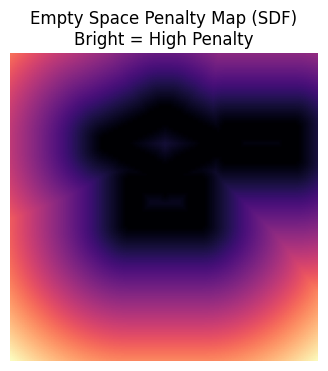

Epoch    0 | Total Loss: 8.59230 | MSE: 0.8559 | SDF: 0.1789
Epoch  200 | Total Loss: 0.50027 | MSE: 0.0495 | SDF: 0.0026
Epoch  400 | Total Loss: 0.36424 | MSE: 0.0354 | SDF: 0.0012
Epoch  600 | Total Loss: 0.21871 | MSE: 0.0203 | SDF: 0.0005
Epoch  800 | Total Loss: 0.15127 | MSE: 0.0130 | SDF: 0.0002
Epoch 1000 | Total Loss: 0.13319 | MSE: 0.0112 | SDF: 0.0002
Epoch 1200 | Total Loss: 0.12764 | MSE: 0.0107 | SDF: 0.0002


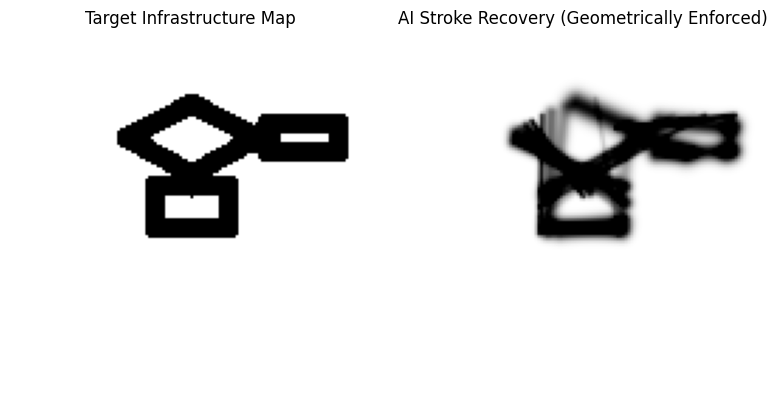


Final Stroke Opacities (Notice which ones dropped near 0.0):
[0.986 0.98  0.04  0.939 0.756 0.065 0.42  0.95  0.158 0.037 0.099 0.124
 0.175 0.174 0.951 0.988 0.219 0.03  0.991 0.978 0.981 0.571 0.416 0.357
 0.777 0.962 0.93 ]
[[0.6604280471801758, 0.3028274476528168, 0.40111133456230164, 0.4495949447154999, 0.5146835446357727, 0.9858186841011047], [0.9142019152641296, 0.26255741715431213, 0.715689480304718, 0.24550725519657135, 0.6326982378959656, 0.9796922206878662], [0.6107335090637207, 0.5530880689620972, 0.40746915340423584, 0.5367846488952637, 0.5129631757736206, 0.9391260147094727], [0.3801294267177582, 0.557876706123352, 0.3878494203090668, 0.2302696257829666, 0.03829579800367355, 0.756101131439209], [0.924564003944397, 0.22865000367164612, 0.597544252872467, 0.26501333713531494, 0.03026377037167549, 0.950225830078125], [0.5010448694229126, 0.45425134897232056, 0.35944488644599915, 0.24507072567939758, 0.01829376444220543, 0.951163649559021], [0.6202725172042847, 0.47262477874

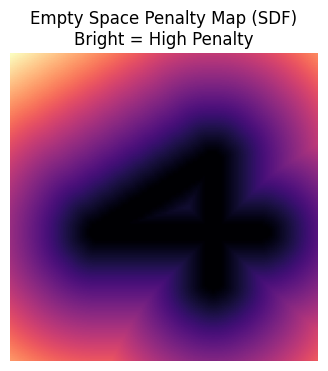

Epoch    0 | Total Loss: 8.57223 | MSE: 0.8538 | SDF: 0.1709
Epoch  200 | Total Loss: 0.39989 | MSE: 0.0395 | SDF: 0.0021
Epoch  400 | Total Loss: 0.29191 | MSE: 0.0282 | SDF: 0.0011
Epoch  600 | Total Loss: 0.16358 | MSE: 0.0149 | SDF: 0.0004
Epoch  800 | Total Loss: 0.08211 | MSE: 0.0064 | SDF: 0.0001
Epoch 1000 | Total Loss: 0.06645 | MSE: 0.0045 | SDF: 0.0001
Epoch 1200 | Total Loss: 0.04616 | MSE: 0.0026 | SDF: 0.0001


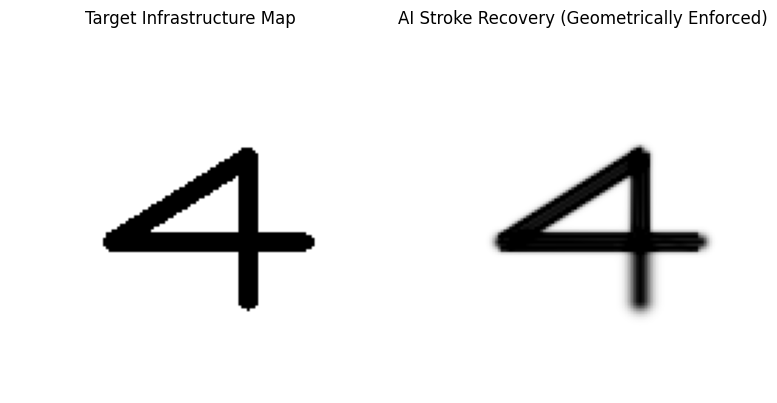


Final Stroke Opacities (Notice which ones dropped near 0.0):
[0.069 0.956 0.965 0.119 0.063 0.836 0.125 0.703 0.988 0.984 0.054 0.335
 0.947 0.283 0.964 0.04  0.745 0.096 0.8   0.041]
[[0.30025339126586914, 0.5960418581962585, 0.6740961074829102, 0.362519770860672, 0.04190760478377342, 0.9561636447906494], [0.6605170965194702, 0.3233238458633423, 0.27268165349960327, 0.5641943216323853, 0.01831512153148651, 0.9649686813354492], [0.681342363357544, 0.338901162147522, 0.6829171180725098, 0.5469610095024109, 0.018038561567664146, 0.8359801769256592], [0.2867453098297119, 0.5614107847213745, 0.6341296434402466, 0.5624675750732422, 0.014725706540048122, 0.7026565074920654], [0.6614429950714111, 0.6157010793685913, 0.6614094376564026, 0.7454493641853333, 0.7935116291046143, 0.9883132576942444], [0.27323028445243835, 0.5813165903091431, 0.8304235339164734, 0.5818858742713928, 0.431001752614975, 0.9840865731239319], [0.32712575793266296, 0.5543778538703918, 0.6492167115211487, 0.3535875082015

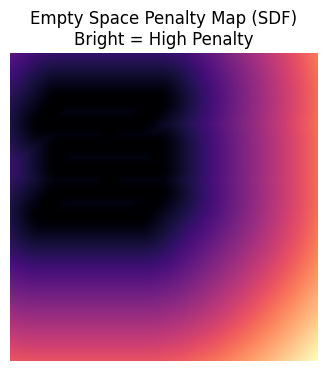

Epoch    0 | Total Loss: 6.22682 | MSE: 0.6196 | SDF: 0.1597
Epoch  200 | Total Loss: 0.44014 | MSE: 0.0433 | SDF: 0.0018
Epoch  400 | Total Loss: 0.37080 | MSE: 0.0360 | SDF: 0.0010
Epoch  600 | Total Loss: 0.21595 | MSE: 0.0205 | SDF: 0.0005
Epoch  800 | Total Loss: 0.14338 | MSE: 0.0131 | SDF: 0.0002
Epoch 1000 | Total Loss: 0.11857 | MSE: 0.0106 | SDF: 0.0002
Epoch 1200 | Total Loss: 0.11590 | MSE: 0.0103 | SDF: 0.0002


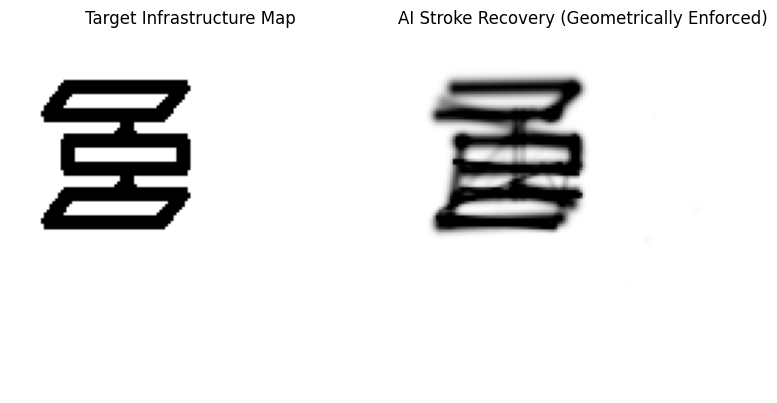


Final Stroke Opacities (Notice which ones dropped near 0.0):
[0.007 0.036 0.018 0.159 0.06  0.007 0.024 0.727 0.999 0.061 0.957 0.026
 0.028 0.997 0.462 0.997 0.954 0.004 0.019 0.977 0.984 0.074 0.027 0.994
 0.001 0.002 0.425 0.165 0.992 0.983 0.031 0.985 0.993 0.264 0.01  0.007
 0.144 0.145]
[[0.16533617675304413, 0.2949056029319763, 0.13030831515789032, 0.5224374532699585, 0.3339102864265442, 0.7269464135169983], [0.4668750762939453, 0.14779193699359894, 0.14513295888900757, 0.1528506875038147, 0.5276233553886414, 0.9989769458770752], [0.4847228527069092, 0.3667839765548706, 0.4825972616672516, 0.3023664951324463, 0.3002694845199585, 0.9574006795883179], [0.10040653496980667, 0.22843001782894135, 0.4236108362674713, 0.22653408348560333, 0.4200758934020996, 0.997010350227356], [0.4715854823589325, 0.29805436730384827, 0.15545915067195892, 0.3008768856525421, 0.4188937842845917, 0.9972941279411316], [0.31498679518699646, 0.4291019141674042, 0.46819746494293213, 0.4752049148082733, 0.4

In [25]:
run_factory()

[sample_01012.png] Dynamically assigned 59 strokes.


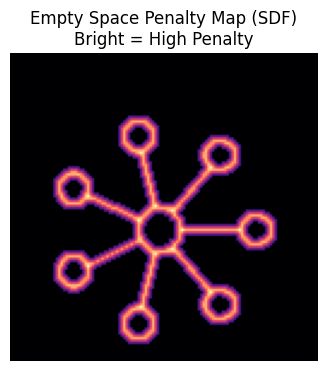

Epoch    0 | Total Loss: 6.53451 | MSE: 0.6505 | SDF: 0.0023
Epoch  200 | Total Loss: 0.71932 | MSE: 0.0712 | SDF: 0.0013
Epoch  400 | Total Loss: 0.58982 | MSE: 0.0580 | SDF: 0.0016
Epoch  600 | Total Loss: 0.43994 | MSE: 0.0430 | SDF: 0.0019
Epoch  800 | Total Loss: 0.42490 | MSE: 0.0414 | SDF: 0.0018
Epoch 1000 | Total Loss: 0.38558 | MSE: 0.0373 | SDF: 0.0019
Epoch 1200 | Total Loss: 0.35086 | MSE: 0.0338 | SDF: 0.0019


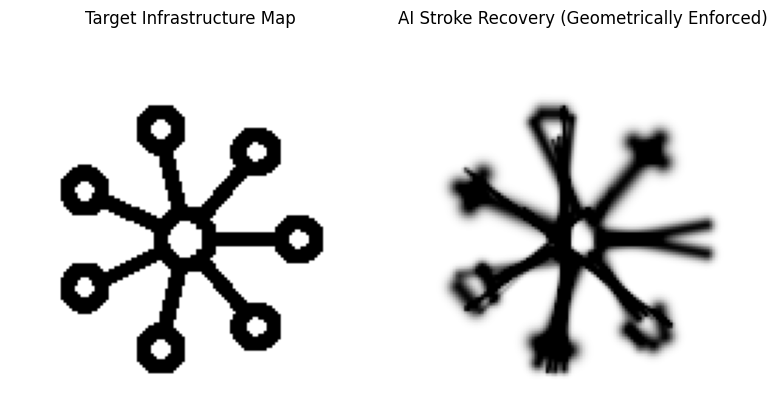


Final Stroke Opacities (Notice which ones dropped near 0.0):
[0.008 0.992 0.859 0.036 0.978 0.767 0.008 0.998 0.397 0.97  0.023 0.701
 0.98  0.95  0.988 0.006 0.006 0.041 0.019 0.985 0.975 0.009 0.015 0.312
 0.082 0.145 0.978 0.986 0.035 0.996 0.987 0.015 0.009 0.959 0.003 0.002
 0.007 0.626 0.989 0.997 0.994 0.934 0.005 0.978 0.302 0.988 0.022 0.094
 0.018 0.944 0.008 0.993 0.96  0.014 0.995 0.008 0.018 0.989 0.015]
[[0.4199773371219635, 0.6114345192909241, 0.2537507712841034, 0.6879393458366394, 0.4875790774822235, 0.9922441840171814], [0.1771850883960724, 0.768811047077179, 0.41165658831596375, 0.6004198789596558, 0.031940244138240814, 0.8587804436683655], [0.4442104697227478, 0.22478216886520386, 0.3886311948299408, 0.22409553825855255, 0.8886717557907104, 0.9781522154808044], [0.6187798976898193, 0.7278956770896912, 0.1745970994234085, 0.3807900846004486, 0.021360347047448158, 0.7672568559646606], [0.42236974835395813, 0.9405887722969055, 0.46008679270744324, 0.6591464281082153, 

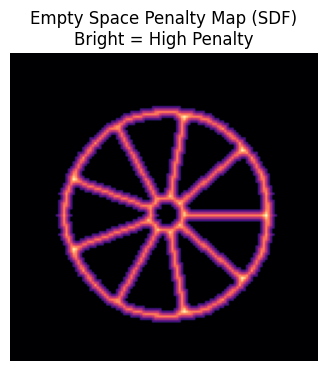

Epoch    0 | Total Loss: 5.91094 | MSE: 0.5880 | SDF: 0.0028
Epoch  200 | Total Loss: 0.96410 | MSE: 0.0957 | SDF: 0.0015
Epoch  400 | Total Loss: 0.66008 | MSE: 0.0649 | SDF: 0.0019
Epoch  600 | Total Loss: 0.36693 | MSE: 0.0353 | SDF: 0.0024
Epoch  800 | Total Loss: 0.28111 | MSE: 0.0268 | SDF: 0.0024
Epoch 1000 | Total Loss: 0.23572 | MSE: 0.0223 | SDF: 0.0025
Epoch 1200 | Total Loss: 0.21193 | MSE: 0.0198 | SDF: 0.0025


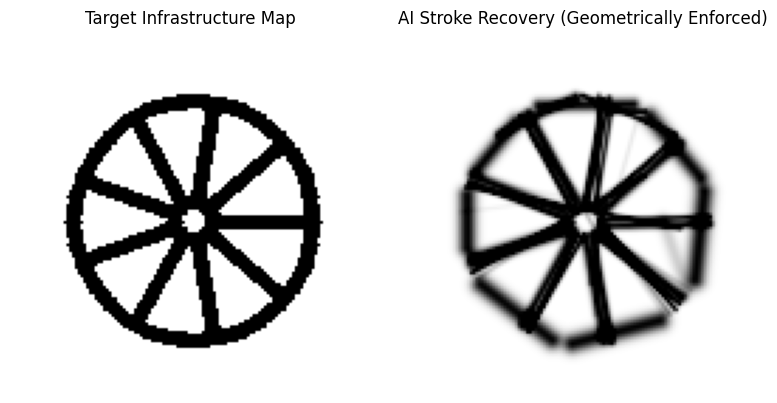


Final Stroke Opacities (Notice which ones dropped near 0.0):
[0.961 0.034 0.107 0.963 0.005 0.988 0.014 0.004 0.987 0.991 0.082 0.025
 0.853 0.004 0.995 0.005 0.986 0.641 0.986 0.261 0.294 0.001 0.998 0.035
 0.01  0.039 0.996 0.184 0.006 0.974 0.995 0.233 0.997 0.373 0.99  0.187
 0.004 0.934 0.143 0.989 0.99  0.902 0.05  0.959 0.006 0.998 0.021 0.994
 0.202 0.112 0.077 0.998 0.002 0.989 0.015 0.983 0.008 0.    0.993 0.003
 0.983 0.992 0.994 0.984 0.97  0.994 0.006 0.995 0.003]
[[0.17772652208805084, 0.4284880459308624, 0.7720401883125305, 0.5442280173301697, 0.0066642072051763535, 0.9610145688056946], [0.7597517371177673, 0.2805405855178833, 0.5008448958396912, 0.173272967338562, 0.07821426540613174, 0.9627978205680847], [0.47214096784591675, 0.8656997680664062, 0.7167704701423645, 0.8015667200088501, 0.9404955506324768, 0.9884585738182068], [0.4812377989292145, 0.17702311277389526, 0.2692805528640747, 0.2816993296146393, 0.5260263681411743, 0.9871779680252075], [0.815204918384552, 0.

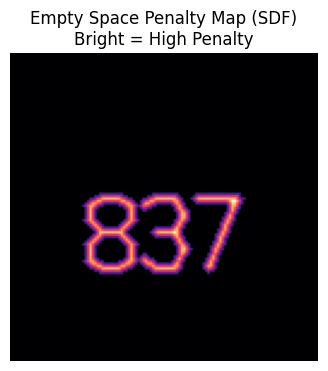

Epoch    0 | Total Loss: 8.61704 | MSE: 0.8587 | SDF: 0.0010
Epoch  200 | Total Loss: 0.41423 | MSE: 0.0409 | SDF: 0.0004
Epoch  400 | Total Loss: 0.36207 | MSE: 0.0354 | SDF: 0.0004
Epoch  600 | Total Loss: 0.23912 | MSE: 0.0226 | SDF: 0.0006
Epoch  800 | Total Loss: 0.14658 | MSE: 0.0129 | SDF: 0.0008
Epoch 1000 | Total Loss: 0.14019 | MSE: 0.0119 | SDF: 0.0008
Epoch 1200 | Total Loss: 0.11905 | MSE: 0.0098 | SDF: 0.0009


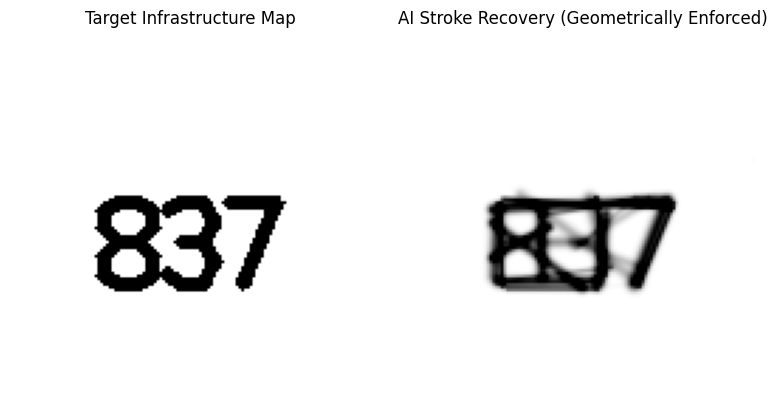


Final Stroke Opacities (Notice which ones dropped near 0.0):
[0.616 0.019 0.854 0.81  0.893 0.185 0.396 0.218 0.308 0.929 0.294 0.841
 0.029 0.815 0.945 0.026 0.615 0.218 0.89  0.285 0.614 0.201 0.89  0.996
 0.091 0.425 0.004 0.489]
[[0.27803274989128113, 0.7069705724716187, 0.2687096893787384, 0.47561800479888916, 0.04032181575894356, 0.6156597137451172], [0.7504238486289978, 0.487854540348053, 0.27955982089042664, 0.4626041352748871, 0.06547301262617111, 0.8540171384811401], [0.4997662305831909, 0.7094596028327942, 0.24971891939640045, 0.5289788246154785, 0.5543729066848755, 0.8096316456794739], [0.5649067759513855, 0.5055922269821167, 0.5421868562698364, 0.7021517157554626, 0.629912257194519, 0.8925592303276062], [0.4041459262371063, 0.5392847657203674, 0.24985653162002563, 0.6264459490776062, 0.5152337551116943, 0.9285097122192383], [0.5392267107963562, 0.45923474431037903, 0.5637301802635193, 0.6743244528770447, 0.14388364553451538, 0.8414665460586548], [0.2574707865715027, 0.676

In [32]:
run_factory()

[sample_01898.png] Dynamically assigned 46 strokes.


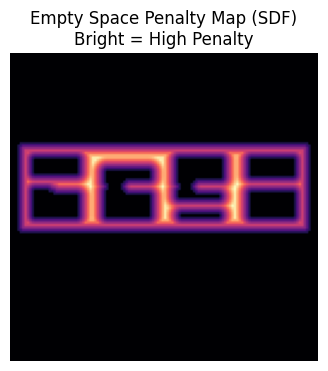

Epoch    0 | Total Loss: 5.83784 | MSE: 0.5808 | SDF: 0.0048
Epoch  200 | Total Loss: 0.68458 | MSE: 0.0668 | SDF: 0.0043
Epoch  400 | Total Loss: 0.52058 | MSE: 0.0506 | SDF: 0.0047
Epoch  600 | Total Loss: 0.18533 | MSE: 0.0172 | SDF: 0.0048
Epoch  800 | Total Loss: 0.13625 | MSE: 0.0120 | SDF: 0.0048
Epoch 1000 | Total Loss: 0.11608 | MSE: 0.0098 | SDF: 0.0048
Epoch 1200 | Total Loss: 0.10185 | MSE: 0.0084 | SDF: 0.0048


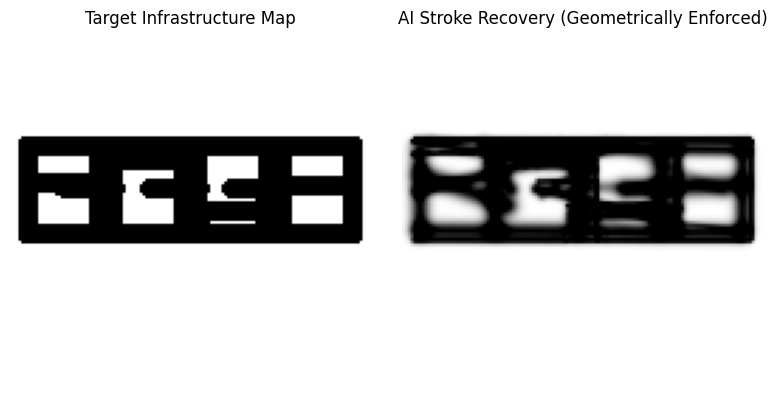


Final Stroke Opacities (Notice which ones dropped near 0.0):
[0.172 0.995 0.011 0.008 0.995 0.994 0.998 0.022 0.488 0.005 0.985 0.994
 0.179 0.992 0.292 0.985 0.89  0.016 0.005 0.994 0.053 0.157 0.999 0.999
 0.003 0.091 0.985 0.479 0.998 0.38  0.986 0.024 0.022 0.998 0.974 0.988
 0.995 0.074 0.006 0.999 0.994 0.011 0.178 0.994 0.998 0.999]
[[0.9721716046333313, 0.3025491237640381, 0.9721645712852478, 0.5727628469467163, 0.059192683547735214, 0.9945635199546814], [0.47078266739845276, 0.5144522786140442, 0.7657774090766907, 0.4891841411590576, 0.648506224155426, 0.9953727126121521], [0.052005600184202194, 0.39416101574897766, 0.2924387454986572, 0.48047834634780884, 0.9672032594680786, 0.9943074584007263], [0.035453785210847855, 0.2933129668235779, 0.9692965149879456, 0.301196426153183, 0.00247121206484735, 0.99774569272995], [0.44691020250320435, 0.5774902105331421, 0.03116769529879093, 0.5771341323852539, 0.2957463562488556, 0.9852553606033325], [0.3015807867050171, 0.434030413627624

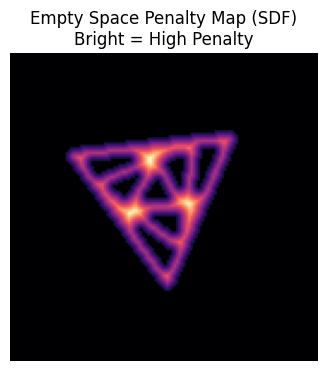

Epoch    0 | Total Loss: 7.79877 | MSE: 0.7768 | SDF: 0.0033
Epoch  200 | Total Loss: 0.39275 | MSE: 0.0383 | SDF: 0.0027
Epoch  400 | Total Loss: 0.29856 | MSE: 0.0282 | SDF: 0.0031
Epoch  600 | Total Loss: 0.22688 | MSE: 0.0205 | SDF: 0.0031
Epoch  800 | Total Loss: 0.11235 | MSE: 0.0084 | SDF: 0.0032
Epoch 1000 | Total Loss: 0.10051 | MSE: 0.0072 | SDF: 0.0032
Epoch 1200 | Total Loss: 0.08156 | MSE: 0.0056 | SDF: 0.0032


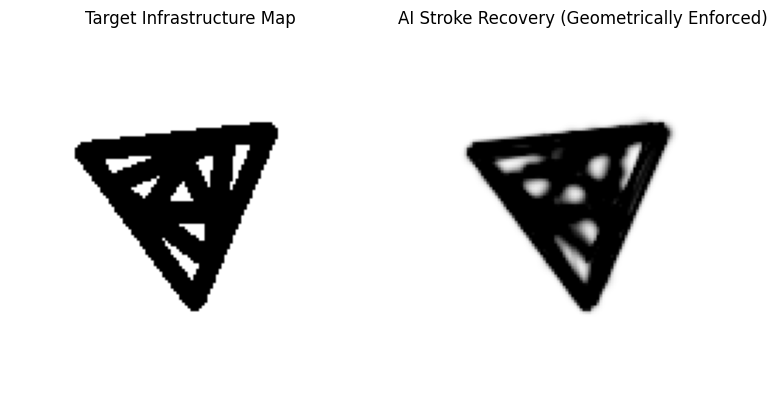


Final Stroke Opacities (Notice which ones dropped near 0.0):
[0.127 0.039 0.964 0.958 0.185 0.763 0.326 0.96  0.973 0.802 0.922 0.754
 0.546 0.885 0.008 0.412 0.938 0.098 0.954 0.955 0.947 0.938 0.778 0.93
 0.823 0.151 0.371]
[[0.5461441874504089, 0.6804919838905334, 0.601824939250946, 0.2943723201751709, 0.8741438984870911, 0.9641280174255371], [0.6706277132034302, 0.273144394159317, 0.32532185316085815, 0.4019927978515625, 0.874130368232727, 0.9584753513336182], [0.4890797734260559, 0.7243515253067017, 0.3005703091621399, 0.4031747281551361, 0.713050127029419, 0.7633010149002075], [0.510204553604126, 0.735896110534668, 0.7236624360084534, 0.27809715270996094, 0.7536563277244568, 0.9595246911048889], [0.5315530300140381, 0.29528936743736267, 0.3548075258731842, 0.522655725479126, 0.8711367845535278, 0.9732855558395386], [0.47106316685676575, 0.2963124215602875, 0.5819432139396667, 0.5813974142074585, 0.7933092713356018, 0.8017975687980652], [0.5057669281959534, 0.6065953373908997, 0.

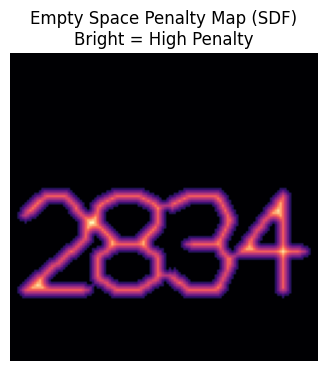

Epoch    0 | Total Loss: 6.02683 | MSE: 0.5997 | SDF: 0.0033
Epoch  200 | Total Loss: 0.92955 | MSE: 0.0916 | SDF: 0.0027
Epoch  400 | Total Loss: 0.72580 | MSE: 0.0713 | SDF: 0.0029
Epoch  600 | Total Loss: 0.25626 | MSE: 0.0242 | SDF: 0.0031
Epoch  800 | Total Loss: 0.19204 | MSE: 0.0174 | SDF: 0.0032
Epoch 1000 | Total Loss: 0.16366 | MSE: 0.0146 | SDF: 0.0032
Epoch 1200 | Total Loss: 0.14113 | MSE: 0.0125 | SDF: 0.0032


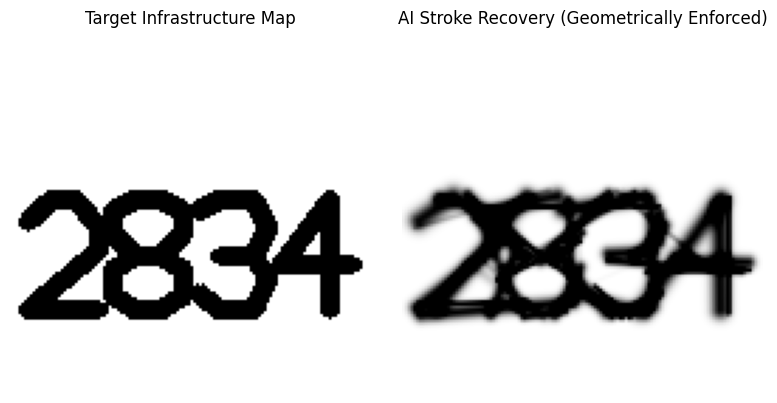


Final Stroke Opacities (Notice which ones dropped near 0.0):
[0.981 0.051 0.951 0.997 0.87  0.997 0.997 0.004 0.996 0.064 0.001 0.921
 0.987 0.565 0.221 0.988 0.981 0.367 0.952 0.998 0.998 0.995 0.998 0.917
 0.987 0.166 0.095 1.    0.982 0.946 0.984 0.997 0.932 0.978 0.048 0.197
 0.983 0.021 0.999 0.026 0.982 0.203 0.113 0.992 0.947 0.247 0.987 0.96
 0.993 0.229]
[[0.20979708433151245, 0.5067376494407654, 0.4296276569366455, 0.4529189467430115, 0.8151676058769226, 0.9807021021842957], [0.4228662848472595, 0.7870397567749023, 0.49460211396217346, 0.6524812579154968, 0.6193415522575378, 0.9506915807723999], [0.6776744723320007, 0.7798828482627869, 0.4965997040271759, 0.7319846153259277, 0.7196700572967529, 0.9965351819992065], [0.17983628809452057, 0.4482525885105133, 0.3246038854122162, 0.7705897688865662, 0.6045997142791748, 0.8701411485671997], [0.9658299684524536, 0.6612361669540405, 0.6780320405960083, 0.6670764684677124, 0.016080323606729507, 0.997258186340332], [0.451791882514953

In [7]:
run_factory()

[sample_00192.png] Dynamically assigned 41 strokes.


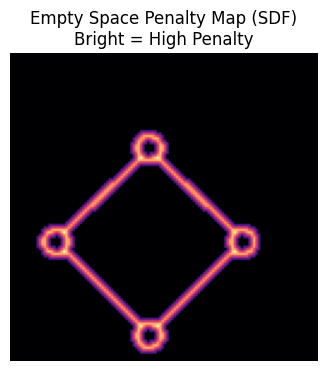

Epoch    0 | Total Loss: 6.00954 | MSE: 0.5980 | SDF: 0.0013
Epoch  200 | Total Loss: 0.41894 | MSE: 0.0411 | SDF: 0.0008
Epoch  400 | Total Loss: 0.28191 | MSE: 0.0271 | SDF: 0.0010
Epoch  600 | Total Loss: 0.17554 | MSE: 0.0164 | SDF: 0.0012
Epoch  800 | Total Loss: 0.14006 | MSE: 0.0126 | SDF: 0.0012
Epoch 1000 | Total Loss: 0.11772 | MSE: 0.0103 | SDF: 0.0012
Epoch 1200 | Total Loss: 0.11478 | MSE: 0.0100 | SDF: 0.0012


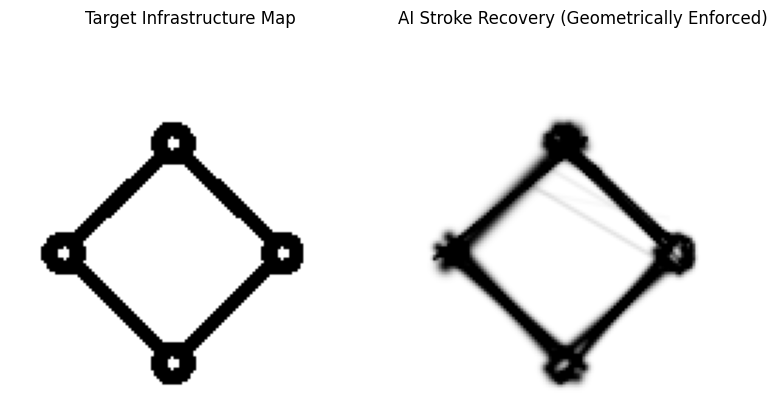


Final Stroke Opacities (Notice which ones dropped near 0.0):
[0.931 0.725 0.932 0.995 0.008 0.025 0.15  0.038 0.138 0.068 0.99  0.009
 0.996 0.013 0.013 0.026 0.095 0.067 0.019 0.982 0.244 0.022 0.032 0.008
 0.985 0.051 0.108 0.989 0.012 0.846 0.201 0.984 0.983 0.686 0.111 0.54
 0.973 0.852 0.965 0.142 0.57 ]
[[0.4314529299736023, 0.26413148641586304, 0.499580979347229, 0.3146762549877167, 0.7347416877746582, 0.9310582876205444], [0.7988176941871643, 0.5765588283538818, 0.6971397995948792, 0.5503894686698914, 0.1364661008119583, 0.7250926494598389], [0.5366019606590271, 0.38627779483795166, 0.3994269371032715, 0.30993595719337463, 0.6108059883117676, 0.9323424696922302], [0.5038217902183533, 0.9320364594459534, 0.09737315028905869, 0.5974879860877991, 0.5702422857284546, 0.9946755170822144], [0.42197364568710327, 0.9553610682487488, 0.4830074608325958, 0.9582496881484985, 0.7429795861244202, 0.9897392392158508], [0.7401030659675598, 0.6488286256790161, 0.40426209568977356, 0.934144496

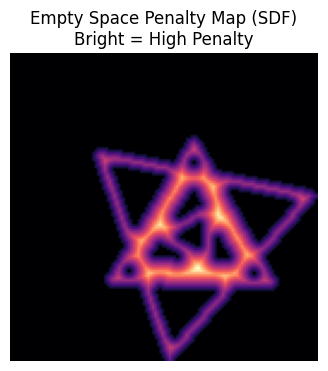

Epoch    0 | Total Loss: 4.99371 | MSE: 0.4962 | SDF: 0.0063
Epoch  200 | Total Loss: 0.50829 | MSE: 0.0494 | SDF: 0.0057
Epoch  400 | Total Loss: 0.28991 | MSE: 0.0276 | SDF: 0.0060
Epoch  600 | Total Loss: 0.16764 | MSE: 0.0151 | SDF: 0.0062
Epoch  800 | Total Loss: 0.14053 | MSE: 0.0121 | SDF: 0.0062
Epoch 1000 | Total Loss: 0.12011 | MSE: 0.0100 | SDF: 0.0062
Epoch 1200 | Total Loss: 0.11931 | MSE: 0.0100 | SDF: 0.0062


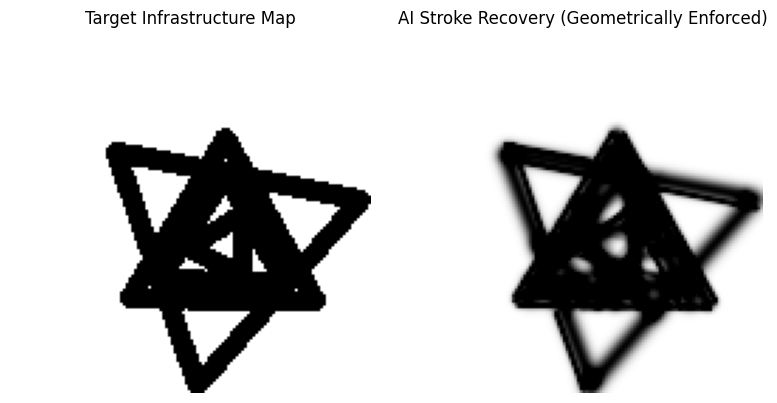


Final Stroke Opacities (Notice which ones dropped near 0.0):
[0.99  0.583 0.999 0.357 1.    0.681 0.994 0.004 0.999 0.125 0.014 0.995
 0.153 0.995 0.916 0.166 0.989 0.997 0.027 0.002 0.996 0.993 0.935 0.025
 0.969 0.985 0.994 0.023 0.997 0.986 0.996 0.012 0.071 0.999 0.023 0.993
 0.988 0.278 0.999 0.992 0.989 1.   ]
[[0.35736024379730225, 0.6923055648803711, 0.5868977308273315, 0.4389075040817261, 0.8592399954795837, 0.989689826965332], [0.4377762973308563, 0.6076027750968933, 0.7130341529846191, 0.6761758327484131, 0.3595609962940216, 0.5830872654914856], [0.616210401058197, 0.2809373438358307, 0.8717283606529236, 0.7433875203132629, 0.014895766042172909, 0.9985852241516113], [0.7968724966049194, 0.6925814151763916, 0.3563621938228607, 0.7312635779380798, 0.9994069337844849, 0.999874472618103], [0.765897274017334, 0.5888702869415283, 0.3261904716491699, 0.7403165102005005, 0.7368471622467041, 0.6805432438850403], [0.59891277551651, 0.3358463644981384, 0.4562176465988159, 0.5400048494

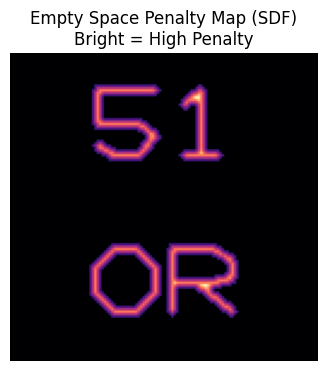

Epoch    0 | Total Loss: 6.76751 | MSE: 0.6738 | SDF: 0.0014
Epoch  200 | Total Loss: 0.54078 | MSE: 0.0534 | SDF: 0.0007
Epoch  400 | Total Loss: 0.42975 | MSE: 0.0421 | SDF: 0.0008
Epoch  600 | Total Loss: 0.35830 | MSE: 0.0348 | SDF: 0.0009
Epoch  800 | Total Loss: 0.30762 | MSE: 0.0297 | SDF: 0.0010
Epoch 1000 | Total Loss: 0.28369 | MSE: 0.0271 | SDF: 0.0011
Epoch 1200 | Total Loss: 0.26938 | MSE: 0.0257 | SDF: 0.0011


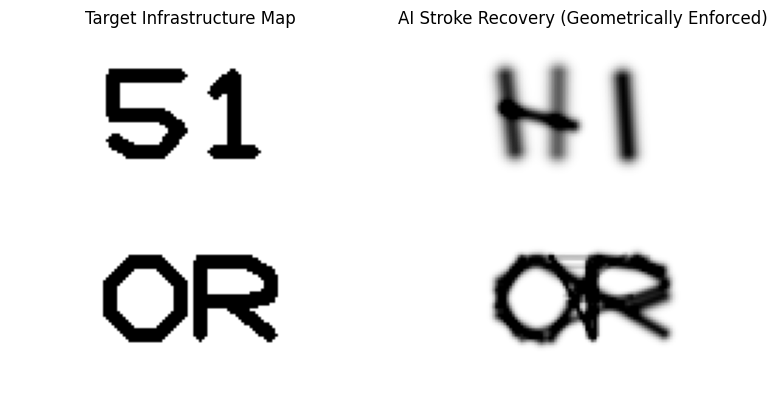


Final Stroke Opacities (Notice which ones dropped near 0.0):
[0.985 0.013 0.388 0.896 0.682 0.015 0.012 0.629 0.972 0.831 0.028 0.023
 0.016 0.15  0.325 0.934 0.016 0.015 0.132 0.85  0.306 0.99  0.005 0.953
 0.098 0.173 0.025 0.029 0.09  0.012 0.067 0.023 0.941 0.005 0.011 0.961
 0.074 0.083 0.969 0.991 0.99  0.916 0.966 0.05 ]
[[0.6120330095291138, 0.12678582966327667, 0.6272112727165222, 0.3321269154548645, 0.9900546073913574, 0.9849164485931396], [0.5164763331413269, 0.6383090615272522, 0.5184816122055054, 0.8448217511177063, 0.12032242119312286, 0.8957481384277344], [0.33236896991729736, 0.8515397310256958, 0.7323222756385803, 0.7044609785079956, 0.517510175704956, 0.681535542011261], [0.43333446979522705, 0.11276110261678696, 0.4304066300392151, 0.3300642669200897, 0.9996390342712402, 0.6286886930465698], [0.38248249888420105, 0.6354163289070129, 0.727468729019165, 0.8368366360664368, 0.6965340971946716, 0.9719299674034119], [0.7293475270271301, 0.690361738204956, 0.6528956294059

In [8]:
run_factory()

[chasma.png] Dynamically assigned 50 strokes.


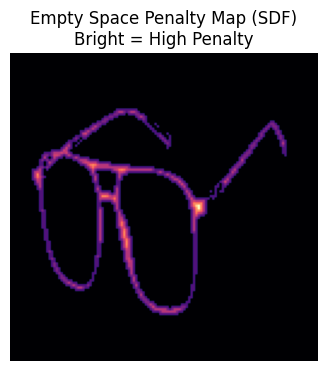

Epoch    0 | Total Loss: 7.25886 | MSE: 0.7229 | SDF: 0.0008
Epoch  200 | Total Loss: 0.55169 | MSE: 0.0546 | SDF: 0.0002
Epoch  400 | Total Loss: 0.49361 | MSE: 0.0487 | SDF: 0.0003
Epoch  600 | Total Loss: 0.42853 | MSE: 0.0420 | SDF: 0.0004
Epoch  800 | Total Loss: 0.34588 | MSE: 0.0335 | SDF: 0.0005
Epoch 1000 | Total Loss: 0.25753 | MSE: 0.0246 | SDF: 0.0006
Epoch 1200 | Total Loss: 0.21050 | MSE: 0.0199 | SDF: 0.0006
Epoch 1400 | Total Loss: 0.20466 | MSE: 0.0193 | SDF: 0.0006
Epoch 1600 | Total Loss: 0.18675 | MSE: 0.0175 | SDF: 0.0006


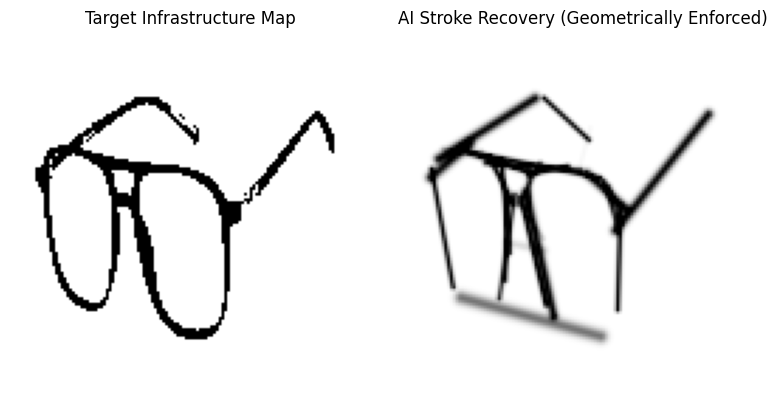


Final Stroke Opacities (Notice which ones dropped near 0.0):
[0.187 0.011 0.013 0.512 0.156 0.033 0.007 0.019 0.888 0.976 0.01  0.942
 0.142 0.013 0.982 0.013 0.076 0.241 0.775 0.037 0.005 0.028 0.033 0.997
 0.819 0.048 0.974 0.005 0.015 0.951 0.829 0.003 0.319 0.024 0.993 0.966
 0.979 0.992 0.754 0.946 0.006 0.009 0.009 0.544 0.09  0.052 0.025 0.993
 0.946 0.004]
[[0.6072444915771484, 0.528076171875, 0.5735709071159363, 0.42522838711738586, 0.09736298769712448, 0.5115073919296265], [0.30426332354545593, 0.475116103887558, 0.24099290370941162, 0.34476611018180847, 0.027163667604327202, 0.8879556655883789], [0.6063324809074402, 0.4793148338794708, 0.5986735820770264, 0.771916925907135, 0.007499872241169214, 0.9762587547302246], [0.3490549921989441, 0.3942051827907562, 0.45886117219924927, 0.3707824647426605, 0.02906832844018936, 0.9421494007110596], [0.36769768595695496, 0.18131732940673828, 0.0983438789844513, 0.3500872850418091, 0.528866171836853, 0.98164302110672], [0.31104296445846

In [24]:
img1 = "./chasma.png"
strokes = optimize_image(img1, epochs=1600)
print(strokes)

